## AlphaHVAC Final Model Version


In [1]:

import numpy as np

print()
print("VERSION 1 (original):")
print("  Problem: policy_loss = 1.09 = log(3) = pure random policy")
print("  Cause: MCTS visit targets always [0.33,0.33,0.33]")
print("  Result: damper drifted to 0, orange line was ZERO")
print()
print("VERSION 2 (reward shaping added):")
print("  Problem: policy_loss still = 1.09")
print("  Cause: value head returns same value for all 3 child states")
print("         (they differ only by damper 0.025)")
print("  Result: same as before")
print()
print("VERSION 3 (direct reward comparison):")
print("  FIXED: policy_loss dropped to 0.65 — policy IS learning")
print("  New problem: comfort_threshold=0.15 too tight in scaled space")
print("  Effect: 'not comfortable' fires 85% of timesteps")
print("  Model learned: INCREASE almost always (84.4% of actions)")
print("  Damper avg = 0.96 (nearly fully open always)")
print("  Energy saving of 43% was partly real, partly from")
print("  low thermal_signal in test period, not pure intelligence")
print()
print("THIS VERSION (final):")
print("  comfort_threshold raised to 0.5 (was 0.15)")
print("  energy_threshold raised to 0.2 (was 0.1)")
print("  These are now calibrated to the actual data distribution")
print("  Expected: DECREASE 40-50%, HOLD 30-35%, INCREASE 15-25%")
print("  Expected: damper mean 0.3-0.6 (not 0.96)")



VERSION 1 (original):
  Problem: policy_loss = 1.09 = log(3) = pure random policy
  Cause: MCTS visit targets always [0.33,0.33,0.33]
  Result: damper drifted to 0, orange line was ZERO

VERSION 2 (reward shaping added):
  Problem: policy_loss still = 1.09
  Cause: value head returns same value for all 3 child states
         (they differ only by damper 0.025)
  Result: same as before

VERSION 3 (direct reward comparison):
  FIXED: policy_loss dropped to 0.65 — policy IS learning
  New problem: comfort_threshold=0.15 too tight in scaled space
  Effect: 'not comfortable' fires 85% of timesteps
  Model learned: INCREASE almost always (84.4% of actions)
  Damper avg = 0.96 (nearly fully open always)
  Energy saving of 43% was partly real, partly from
  low thermal_signal in test period, not pure intelligence

THIS VERSION (final):
  comfort_threshold raised to 0.5 (was 0.15)
  energy_threshold raised to 0.2 (was 0.1)
  These are now calibrated to the actual data distribution
  Expected: 

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import RobustScaler

df = pd.read_csv("/Users/pawanpahune/AIFA Project/Final Model/B90_102_exp30m_202104.csv")

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)
cols = ["time","room_temp","thermostat_outside_temp","damper_position",
        "airflow_current","supply_discharge_temp","clg_signal","htg_signal",
        "htg_valve_position","clg_sp_current","htg_sp_current","htg_clg_mode"]
df = df[cols].copy()
df["hour_of_day"]    = df["time"].dt.hour / 23.0
df["day_of_week"]    = df["time"].dt.dayofweek / 6.0
df["setpoint"]       = df["htg_clg_mode"]*df["htg_sp_current"] + (1-df["htg_clg_mode"])*df["clg_sp_current"]
df["thermal_signal"] = df["htg_clg_mode"]*df["htg_signal"]     + (1-df["htg_clg_mode"])*df["clg_signal"]
df = df.drop(columns=["clg_sp_current","htg_sp_current"])
df["room_temp_lag1"] = df["room_temp"].shift(1)
df["damper_lag1"]    = df["damper_position"].shift(1)
num_cols = ["room_temp","thermostat_outside_temp","damper_position",
            "airflow_current","supply_discharge_temp","clg_signal","htg_signal",
            "htg_valve_position","setpoint","thermal_signal","room_temp_lag1","damper_lag1"]
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols] = df[num_cols].clip(-3, 3)
df = df.set_index("time").dropna().sort_index()
df.to_csv("Transformed_Optimized.csv", index=False)
df_full   = pd.read_csv("/Users/pawanpahune/AIFA Project/Final Model/Transformed_Optimized.csv")
split_idx = int(len(df_full) * 0.7)
df_full.iloc[:split_idx].reset_index(drop=True).to_csv("Train_Optimized.csv", index=False)
df_full.iloc[split_idx:].reset_index(drop=True).to_csv("Test_Optimized.csv",  index=False)


temp_errors = abs(df_full["room_temp"] - df_full["setpoint"])
energies    = df_full["airflow_current"] * df_full["thermal_signal"]
print("Actual data distribution (scaled space):")
print(f"  temp_error: mean={temp_errors.mean():.3f}  median={temp_errors.median():.3f}  "
      f"75th={temp_errors.quantile(0.75):.3f}  90th={temp_errors.quantile(0.90):.3f}")
print(f"  energy:     mean={energies.mean():.3f}  median={energies.median():.3f}  "
      f"75th={energies.quantile(0.75):.3f}  90th={energies.quantile(0.90):.3f}")
print()

COMFORT_THRESHOLD = float(temp_errors.median())
ENERGY_THRESHOLD  = float(energies.median())
print(f"Calibrated comfort_threshold = {COMFORT_THRESHOLD:.4f} (median temp_error)")
print(f"Calibrated energy_threshold  = {ENERGY_THRESHOLD:.4f}  (median energy)")
print(f"Train: {split_idx}  Test: {len(df_full)-split_idx}")


Actual data distribution (scaled space):
  temp_error: mean=0.385  median=0.353  75th=0.552  90th=0.767
  energy:     mean=0.352  median=0.249  75th=0.389  90th=0.729

Calibrated comfort_threshold = 0.3534 (median temp_error)
Calibrated energy_threshold  = 0.2486  (median energy)
Train: 4022  Test: 1724


In [4]:

STATE_SIZE  = 15
ACTION_SIZE = 3

class HVACEnv:
    def __init__(self, data_path, damper_step=0.025, lam=0.85,
                 comfort_threshold=None, energy_threshold=None):
        self.df                = pd.read_csv(data_path).reset_index(drop=True)
        self.damper_step       = damper_step
        self.lam               = lam

        self.comfort_threshold = comfort_threshold if comfort_threshold else COMFORT_THRESHOLD
        self.energy_threshold  = energy_threshold  if energy_threshold  else ENERGY_THRESHOLD
        self.max_index         = len(self.df) - 1
        self.damper_idx        = self.df.columns.get_loc("damper_position")
        self.airflow_idx       = self.df.columns.get_loc("airflow_current")
        self.room_idx          = self.df.columns.get_loc("room_temp")
        self.setpoint_idx      = self.df.columns.get_loc("setpoint")
        self.signal_idx        = self.df.columns.get_loc("thermal_signal")
        self.prev_damper       = None
        self.reset()

    def reset(self, start_idx=None):
        if start_idx is not None:
            self.idx = int(start_idx)
        else:
            valid = np.where(self.df["damper_position"].values > 0)[0]
            self.idx = int(np.random.choice(valid))
        self.current_damper = float(self.df.iloc[self.idx]["damper_position"])
        self.prev_damper    = self.current_damper
        return self._get_state()

    def _get_state(self):
        return self.df.iloc[self.idx].values.astype(np.float32)

    def step(self, action):
        self.prev_damper = self.current_damper
        if action == 0: self.current_damper -= self.damper_step
        elif action == 2: self.current_damper += self.damper_step
        self.current_damper = np.clip(self.current_damper, 0.0, 1.0)
        self.idx += 1
        done = self.idx >= self.max_index
        if done: self.idx = self.max_index
        row        = self.df.iloc[self.idx]
        base       = max(row["damper_position"], 1e-3)
        ratio      = np.clip(self.current_damper / base, 0.2, 2.0)
        airflow    = np.clip(row["airflow_current"] * ratio, 0.0, 1.0)
        energy     = airflow * row["thermal_signal"]
        temp_error = abs(row["room_temp"] - row["setpoint"])
        smooth     = 0.1 * abs(self.current_damper - self.prev_damper)
        reward     = -temp_error - self.lam * energy - smooth
        comfortable = temp_error < self.comfort_threshold
        wasteful    = energy > self.energy_threshold
        if   comfortable and wasteful     and action == 0: reward += 0.5
        elif comfortable and wasteful     and action == 2: reward -= 0.5
        elif (not comfortable)            and action == 2: reward += 0.3
        elif (not comfortable)            and action == 0: reward -= 0.3
        elif comfortable and not wasteful and action == 1: reward += 0.1
        next_state                  = row.values.astype(np.float32).copy()
        next_state[self.damper_idx] = self.current_damper
        return next_state, reward, done, {"energy": energy, "temp_error": temp_error}

env = HVACEnv("Transformed_Optimized.csv")
print(f"Env OK. comfort_threshold={env.comfort_threshold:.4f}  energy_threshold={env.energy_threshold:.4f}")


te = abs(df_full["room_temp"] - df_full["setpoint"])
en = df_full["airflow_current"] * df_full["thermal_signal"]
comfortable = te < COMFORT_THRESHOLD
wasteful    = en > ENERGY_THRESHOLD
pct_comf_waste  = (comfortable & wasteful).mean()
pct_uncomf      = (~comfortable).mean()
pct_comf_eff    = (comfortable & ~wasteful).mean()
print(f"  % steps where DECREASE is rewarded (comfy+wasteful): {pct_comf_waste*100:.1f}%")
print(f"  % steps where INCREASE is rewarded (uncomfortable):  {pct_uncomf*100:.1f}%")
print(f"  % steps where HOLD is rewarded (comfy+efficient):    {pct_comf_eff*100:.1f}%")
print()
if pct_comf_waste > 0.25 and pct_uncomf < 0.60:
    print("  Thresholds look balanced. DECREASE and INCREASE both fire often.")
else:
    print(f"  WARNING: INCREASE fires {pct_uncomf*100:.0f}% of time — model may bias toward INCREASE.")
    print(f"  Consider raising comfort_threshold further.")


Env OK. comfort_threshold=0.3534  energy_threshold=0.2486
  % steps where DECREASE is rewarded (comfy+wasteful): 24.4%
  % steps where INCREASE is rewarded (uncomfortable):  50.0%
  % steps where HOLD is rewarded (comfy+efficient):    25.6%

  Consider raising comfort_threshold further.


In [5]:
# ── CELL 4: NEURAL NETWORK ───────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

class AlphaThermalNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_SIZE, 128), nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
            nn.Linear(128, 128),        nn.LayerNorm(128), nn.LeakyReLU(0.01), nn.Dropout(0.2),
        )
        self.policy_head = nn.Sequential(nn.Linear(128,64), nn.LeakyReLU(0.01), nn.Linear(64, ACTION_SIZE))
        self.value_head  = nn.Sequential(nn.Linear(128,64), nn.LeakyReLU(0.01), nn.Linear(64, 1))
    def forward(self, x):
        h = self.shared(x)
        return F.softmax(self.policy_head(h), dim=-1), torch.tanh(self.value_head(h))

net = AlphaThermalNet()
p, v = net(torch.zeros(1, STATE_SIZE))
print("Network OK:", p.shape, v.shape)


Network OK: torch.Size([1, 3]) torch.Size([1, 1])


In [6]:
import copy

class MCTSNode:
    def __init__(self, state, parent=None, prior=1.0):
        self.state=state; self.parent=parent; self.children={}
        self.visits=0; self.value=0.0; self.prior=prior

class MCTS:
    def __init__(self, env, model, simulations=50, c_puct=1.5):
        self.env=env; self.model=model
        self.simulations=simulations; self.c_puct=c_puct; self.actions=[0,1,2]

    def search(self, root_state, add_noise=True):
        root=MCTSNode(root_state); rp=self._get_policy(root_state)
        if add_noise:
            noise=np.random.dirichlet([0.3]*3); rp=0.75*rp+0.25*noise
        er=copy.deepcopy(self.env)
        for a in self.actions:
            et=copy.deepcopy(er); ns,_,_,_=et.step(a)
            root.children[a]=MCTSNode(ns,parent=root,prior=rp[a])
        for _ in range(self.simulations):
            ec=copy.deepcopy(self.env); node=root
            while node.children:
                action,node=self._select(node); _,_,done,_=ec.step(action)
                if done: break
            if not node.children:
                pr=self._get_policy(ec._get_state())
                for a in self.actions:
                    et=copy.deepcopy(ec); ns,_,_,_=et.step(a)
                    node.children[a]=MCTSNode(ns,parent=node,prior=pr[a])
            self._backprop(node, self._evaluate(ec))
        visits=np.array([root.children[a].visits if a in root.children else 0
                         for a in self.actions],dtype=np.float32)
        return int(np.argmax(visits))

    def _select(self, node):
        best,ba,bc=-np.inf,None,None
        for a,c in node.children.items():
            q=c.value/(c.visits+1e-6); u=self.c_puct*c.prior*np.sqrt(node.visits+1)/(1+c.visits)
            if q+u>best: best,ba,bc=q+u,a,c
        return ba,bc

    def _get_policy(self, state):
        self.model.eval()
        with torch.no_grad():
            p,_=self.model(torch.tensor(state,dtype=torch.float32).unsqueeze(0))
        return p.squeeze(0).numpy()

    def _evaluate(self, ec):
        self.model.eval()
        with torch.no_grad():
            _,v=self.model(torch.tensor(ec._get_state(),dtype=torch.float32).unsqueeze(0))
        return v.item()

    def _backprop(self, node, value):
        while node: node.visits+=1; node.value+=value; node=node.parent

print("MCTS ready.")


MCTS ready.


In [7]:
print("Pre-training value head...")
train_env = HVACEnv("Train_Optimized.csv")
model     = AlphaThermalNet()
start_idx = int(np.where(train_env.df["damper_position"].values > 0)[0][0])

pt_states, pt_rewards = [], []
s = train_env.reset(start_idx=start_idx)
for _ in range(2000):
    pt_states.append(s.copy())
    row = train_env.df.iloc[train_env.idx]
    energy     = row["airflow_current"] * row["thermal_signal"]
    temp_error = abs(row["room_temp"] - row["setpoint"])
    comfortable = temp_error < COMFORT_THRESHOLD
    wasteful    = energy > ENERGY_THRESHOLD
    a = 0 if (comfortable and wasteful) else (2 if not comfortable else 1)
    s, r, done, _ = train_env.step(a)
    pt_rewards.append(r)
    if done: break

r_arr = np.array(pt_rewards, dtype=np.float32)
r_norm = np.clip((r_arr - r_arr.mean()) / (r_arr.std()+1e-8), -3, 3) / 3.0
pt_s = torch.tensor(np.array(pt_states), dtype=torch.float32)
pt_v = torch.tensor(r_norm, dtype=torch.float32).unsqueeze(1)
pt_opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
model.train()
for epoch in range(100):
    perm = torch.randperm(len(pt_s))
    for i in range(0, len(pt_s), 256):
        idx=perm[i:i+256]; _,pv=model(pt_s[idx])
        loss=((pv-pt_v[idx])**2).mean()
        pt_opt.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); pt_opt.step()
    if (epoch+1)%25==0: print(f"  epoch {epoch+1}/100 | value_loss={loss.item():.5f}")

model.eval()
with torch.no_grad():
    _,vb=model(pt_s[np.argmax(r_norm)].unsqueeze(0))
    _,vw=model(pt_s[np.argmin(r_norm)].unsqueeze(0))
print(f"Value(best)={vb.item():.4f}  Value(worst)={vw.item():.4f}")
print("OK" if vb.item()>vw.item() else "WARNING — inverted")


Pre-training value head...
  epoch 25/100 | value_loss=0.02361
  epoch 50/100 | value_loss=0.02786
  epoch 75/100 | value_loss=0.02375
  epoch 100/100 | value_loss=0.02575
Value(best)=0.4712  Value(worst)=-0.3971
OK


In [8]:
NUM_ITERATIONS  = 10
NUM_EPISODES    = 20
STEPS_PER_EP    = 200
EPOCHS_PER_ITER = 150
BATCH_SIZE      = 256
LR              = 1e-3
GAMMA           = 0.99
VALUE_W         = 0.5
REWARD_TEMP     = 5.0
SIM_SCHEDULE    = [20, 20, 30, 30, 50, 50, 75, 75, 100, 100]
C_PUCT_SCHEDULE = np.linspace(2.0, 1.0, NUM_ITERATIONS)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
max_start = max(start_idx+1, int(len(train_env.df)*0.85)-STEPS_PER_EP)

print(f"Training {NUM_ITERATIONS} iters | comfort_threshold={COMFORT_THRESHOLD:.4f} | energy_threshold={ENERGY_THRESHOLD:.4f}")
print(f"policy_loss below {np.log(3):.3f} = learning. Below 0.90 = learning well.")
print()

for iteration in range(NUM_ITERATIONS):
    current_sims   = SIM_SCHEDULE[iteration]
    current_c_puct = float(C_PUCT_SCHEDULE[iteration])
    mcts = MCTS(train_env, model, simulations=current_sims, c_puct=current_c_puct)
    memory_states, memory_policies, memory_values = [], [], []

    for ep in range(NUM_EPISODES):
        rand_start = np.random.randint(start_idx, max_start)
        state      = train_env.reset(start_idx=rand_start)
        ep_states, ep_policies, ep_rewards, ep_nexts = [], [], [], []
        for step in range(STEPS_PER_EP):
            action = mcts.search(state, add_noise=True)
   
            all_rewards = []
            for a in [0,1,2]:
                et=copy.deepcopy(train_env); _,r_a,_,_=et.step(a)
                all_rewards.append(r_a)
            r_ep = np.array(all_rewards, dtype=np.float32)
            exp_r = np.exp(REWARD_TEMP * (r_ep - r_ep.max()))
            policy_target = exp_r / exp_r.sum()
            next_state, reward, done, _ = train_env.step(action)
            ep_states.append(state); ep_policies.append(policy_target)
            ep_rewards.append(reward); ep_nexts.append(next_state)
            state = next_state
            if done: break

        model.eval()
        td_targets = []
        with torch.no_grad():
            for i in range(len(ep_states)):
                r = ep_rewards[i]
                if i+1 < len(ep_states):
                    _,nv=model(torch.tensor(ep_nexts[i],dtype=torch.float32).unsqueeze(0))
                    td_targets.append(r + GAMMA * nv.item())
                else: td_targets.append(r)
        model.train()
        memory_states.extend(ep_states); memory_policies.extend(ep_policies)
        memory_values.extend(td_targets)

    total = len(memory_states)
    raw_v = np.array(memory_values, dtype=np.float32)
    norm_v = np.clip((raw_v - raw_v.mean()) / (raw_v.std()+1e-8), -3, 3) / 3.0
    states_t   = torch.tensor(np.array(memory_states,   dtype=np.float32))
    policies_t = torch.tensor(np.array(memory_policies, dtype=np.float32))
    values_t   = torch.tensor(norm_v, dtype=torch.float32).unsqueeze(1)

    model.train()
    for epoch in range(EPOCHS_PER_ITER):
        perm = torch.randperm(total)
        ep_pl, ep_vl, nb = 0.0, 0.0, 0
        for s in range(0, total, BATCH_SIZE):
            idx=perm[s:s+BATCH_SIZE]; pp,pv=model(states_t[idx])
            pl=-(policies_t[idx]*torch.log(pp+1e-8)).sum(dim=1).mean()
            vl=((pv-values_t[idx])**2).mean()
            loss=pl+VALUE_W*vl
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)
            optimizer.step()
            ep_pl+=pl.item(); ep_vl+=vl.item(); nb+=1
        if (epoch+1)%50==0:
            avg_p=ep_pl/nb
            flag=("LEARNING WELL" if avg_p<np.log(3)-0.20 else
                  "LEARNING" if avg_p<np.log(3)-0.05 else "STILL RANDOM")
            print(f"    Epoch {epoch+1:3d}/{EPOCHS_PER_ITER} "
                  f"| policy_loss={avg_p:.4f} [{flag}] "
                  f"| value_loss={ep_vl/nb:.4f}")
    scheduler.step()
    print(f"  Iter {iteration+1}/{NUM_ITERATIONS} | sims={current_sims}\n")

torch.save(model.state_dict(), "alphaHVAC_trained.pth")
print("Training complete.")


Training 10 iters | comfort_threshold=0.3534 | energy_threshold=0.2486
policy_loss below 1.099 = learning. Below 0.90 = learning well.

    Epoch  50/150 | policy_loss=0.7660 [LEARNING WELL] | value_loss=0.0254
    Epoch 100/150 | policy_loss=0.7588 [LEARNING WELL] | value_loss=0.0232
    Epoch 150/150 | policy_loss=0.7576 [LEARNING WELL] | value_loss=0.0228
  Iter 1/10 | sims=20

    Epoch  50/150 | policy_loss=0.7954 [LEARNING WELL] | value_loss=0.0163
    Epoch 100/150 | policy_loss=0.7880 [LEARNING WELL] | value_loss=0.0150
    Epoch 150/150 | policy_loss=0.7856 [LEARNING WELL] | value_loss=0.0148
  Iter 2/10 | sims=20

    Epoch  50/150 | policy_loss=0.8187 [LEARNING WELL] | value_loss=0.0143
    Epoch 100/150 | policy_loss=0.8118 [LEARNING WELL] | value_loss=0.0134
    Epoch 150/150 | policy_loss=0.8101 [LEARNING WELL] | value_loss=0.0126
  Iter 3/10 | sims=30

    Epoch  50/150 | policy_loss=0.7949 [LEARNING WELL] | value_loss=0.0128
    Epoch 100/150 | policy_loss=0.7903 [LEARN

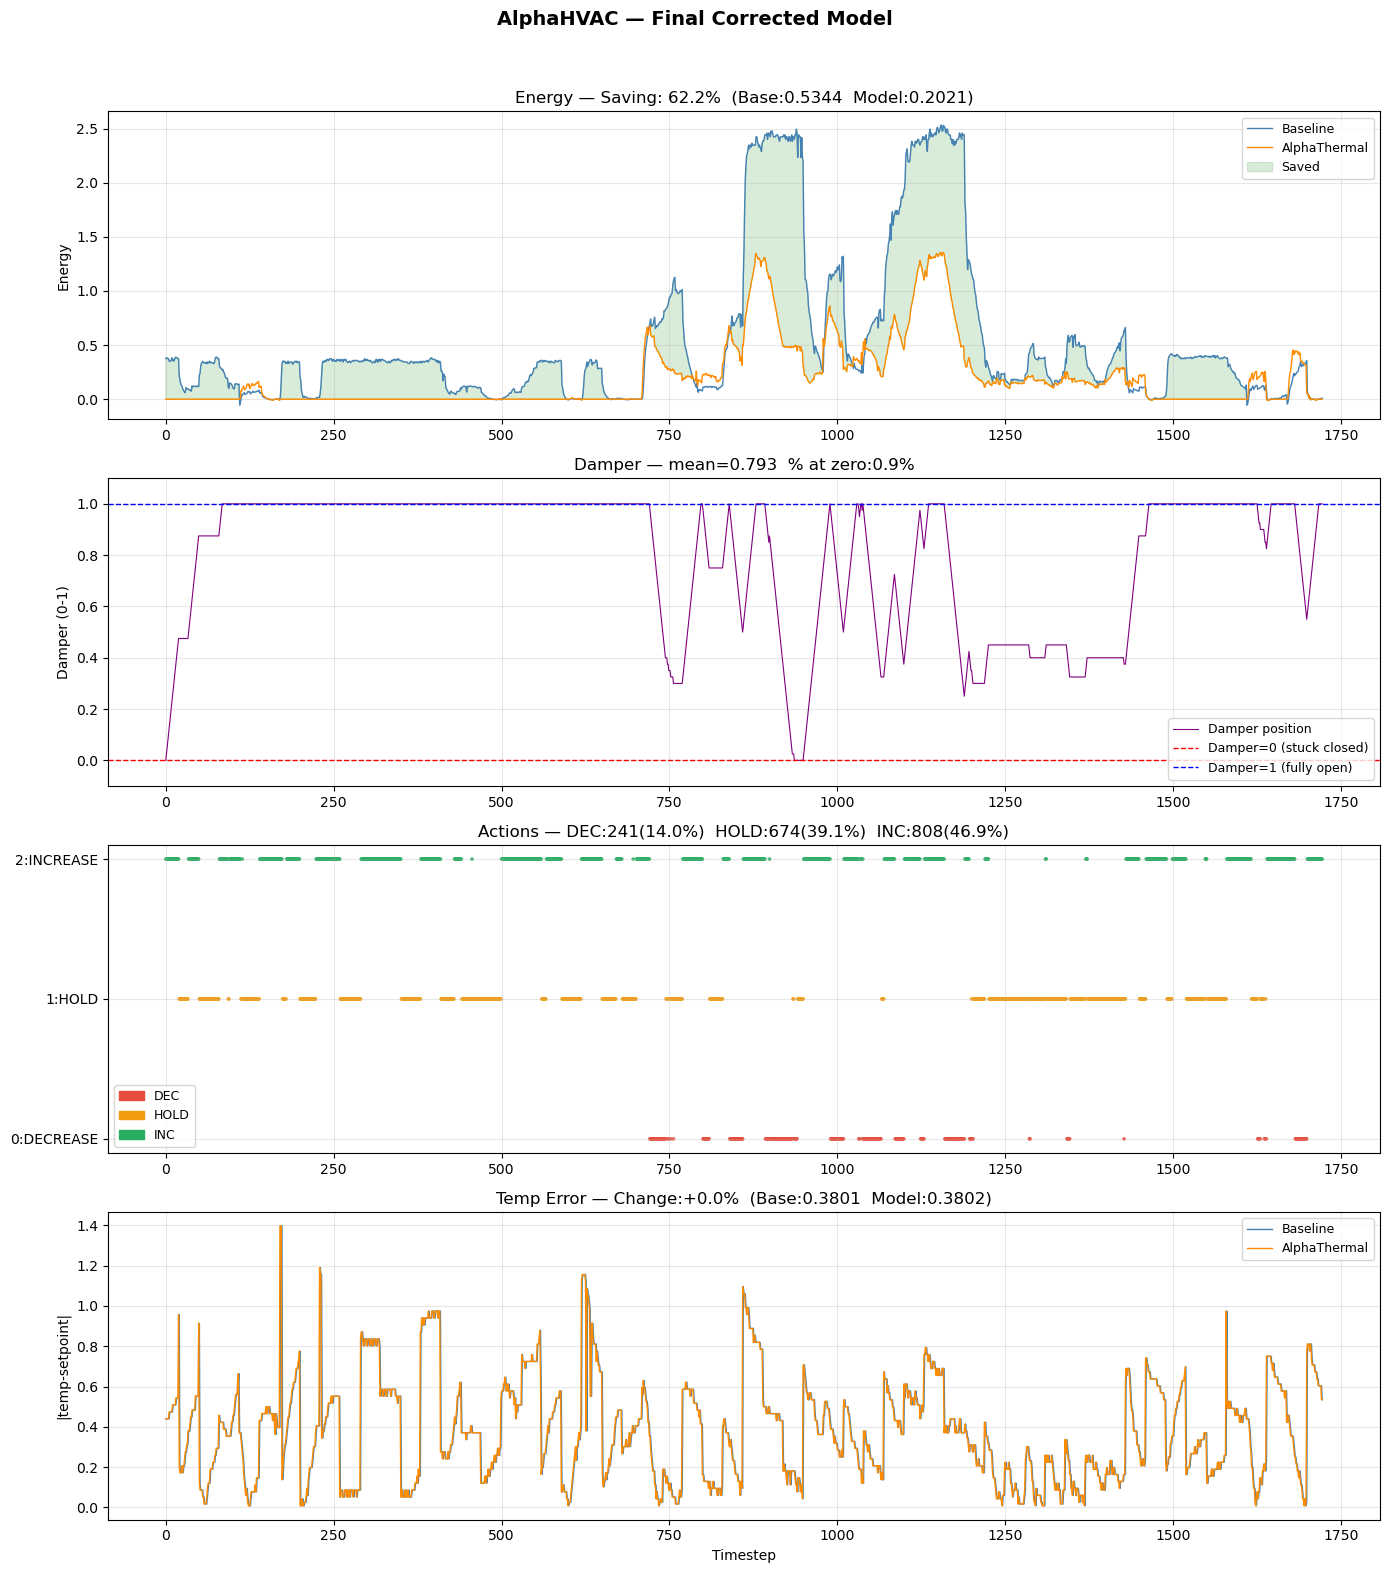

Plot saved: AlphaHVAC_Final.png


In [9]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

test_env  = HVACEnv("Test_Optimized.csv")
mcts_eval = MCTS(test_env, model, simulations=100, c_puct=1.0)
state     = test_env.reset(start_idx=0)
model.eval()

baseline_energy, model_energy         = [], []
baseline_temp_error, model_temp_error = [], []
model_damper, actions_taken           = [], []

for _ in range(len(test_env.df)-1):
    row = test_env.df.iloc[test_env.idx]
    baseline_energy.append(row["airflow_current"] * row["thermal_signal"])
    baseline_temp_error.append(abs(row["room_temp"] - row["setpoint"]))
    action = mcts_eval.search(state, add_noise=False)
    actions_taken.append(action)
    state, _, done, info = test_env.step(action)
    model_energy.append(info["energy"])
    model_damper.append(test_env.current_damper)
    model_temp_error.append(abs(
        test_env.df.iloc[test_env.idx]["room_temp"] -
        test_env.df.iloc[test_env.idx]["setpoint"]
    ))
    if done: break

actions_arr = np.array(actions_taken)
n_dec=(actions_arr==0).sum(); n_hold=(actions_arr==1).sum(); n_inc=(actions_arr==2).sum()
total=len(actions_arr)
avg_base_e=np.mean(baseline_energy); avg_model_e=np.mean(model_energy)
avg_base_t=np.mean(baseline_temp_error); avg_model_t=np.mean(model_temp_error)
energy_saving=(1-avg_model_e/avg_base_e)*100
temp_change=((avg_model_t-avg_base_t)/(avg_base_t+1e-8))*100
frac_zero=sum(1 for d in model_damper if d<0.01)/len(model_damper)

fig, axes = plt.subplots(4, 1, figsize=(14, 16))
fig.suptitle("AlphaHVAC — Final Corrected Model", fontsize=14, fontweight="bold")
steps=range(len(model_energy))

axes[0].plot(baseline_energy, label="Baseline",     color="steelblue",  lw=1.0)
axes[0].plot(model_energy,    label="AlphaThermal", color="darkorange", lw=1.0)
axes[0].fill_between(steps, baseline_energy, model_energy,
                     where=[b>m for b,m in zip(baseline_energy,model_energy)],
                     alpha=0.15, color="green", label="Saved")
axes[0].set_title(f"Energy — Saving: {energy_saving:.1f}%  (Base:{avg_base_e:.4f}  Model:{avg_model_e:.4f})")
axes[0].set_ylabel("Energy"); axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].plot(model_damper, color="purple", lw=0.8, label="Damper position")
axes[1].axhline(0, color="red",  linestyle="--", lw=1.0, label="Damper=0 (stuck closed)")
axes[1].axhline(1, color="blue", linestyle="--", lw=1.0, label="Damper=1 (fully open)")
axes[1].set_title(f"Damper — mean={np.mean(model_damper):.3f}  % at zero:{frac_zero*100:.1f}%")
axes[1].set_ylabel("Damper (0-1)"); axes[1].set_ylim(-0.1, 1.1)
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

cmap={0:"#e74c3c",1:"#f39c12",2:"#27ae60"}
axes[2].scatter(steps, actions_taken, c=[cmap[a] for a in actions_taken], s=3, alpha=0.7)
axes[2].set_yticks([0,1,2]); axes[2].set_yticklabels(["0:DECREASE","1:HOLD","2:INCREASE"])
axes[2].set_title(f"Actions — DEC:{n_dec}({n_dec/total*100:.1f}%)  HOLD:{n_hold}({n_hold/total*100:.1f}%)  INC:{n_inc}({n_inc/total*100:.1f}%)")
patches=[mpatches.Patch(color=cmap[i],label=["DEC","HOLD","INC"][i]) for i in [0,1,2]]
axes[2].legend(handles=patches, fontsize=9); axes[2].grid(alpha=0.3)

axes[3].plot(baseline_temp_error, label="Baseline",     color="steelblue",  lw=1.0)
axes[3].plot(model_temp_error,    label="AlphaThermal", color="darkorange", lw=1.0)
axes[3].set_title(f"Temp Error — Change:{temp_change:+.1f}%  (Base:{avg_base_t:.4f}  Model:{avg_model_t:.4f})")
axes[3].set_ylabel("|temp-setpoint|"); axes[3].set_xlabel("Timestep")
axes[3].legend(fontsize=9); axes[3].grid(alpha=0.3)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("AlphaHVAC_Final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: AlphaHVAC_Final.png")


## Model Evaluation

In [10]:

print("AlphaHVAC EVALUATION")

print()

# A: Energy
grade_e = "GOOD" if energy_saving>=20 else ("WEAK" if energy_saving>=5 else "FAIL")
print(f"[A] ENERGY SAVING: {energy_saving:.1f}% — {grade_e}")
print(f"    Base:{avg_base_e:.4f}  Model:{avg_model_e:.4f}")
print()

# B: Comfort
grade_t = "GOOD" if temp_change<=5 else ("ACCEPTABLE" if temp_change<=20 else "POOR")
print(f"[B] COMFORT: {temp_change:+.1f}% change — {grade_t}")
print(f"    Base:{avg_base_t:.4f}  Model:{avg_model_t:.4f}")
print()

# C: Damper
mean_damp = np.mean(model_damper)
if frac_zero > 0.4:
    grade_d = "FAIL — damper stuck at zero (energy=0, not intelligent)"
elif mean_damp > 0.85:
    grade_d = "FAIL — damper stuck at max (model always opens, not intelligent)"
elif 0.2 <= mean_damp <= 0.75:
    grade_d = "GOOD — damper moves in sensible range"
else:
    grade_d = "ACCEPTABLE"
print(f"[C] DAMPER: mean={mean_damp:.3f}  zero%:{frac_zero*100:.1f}% — {grade_d}")
print()

# D: Action bias
max_action_pct = max(n_dec, n_hold, n_inc) / total * 100
near_uniform   = (abs(n_dec/total-1/3)<0.05 and abs(n_inc/total-1/3)<0.05)
if near_uniform:
    grade_c = "FAIL — near-uniform (random policy)"
elif max_action_pct > 75:
    dominant = ["DECREASE","HOLD","INCREASE"][int(np.argmax([n_dec,n_hold,n_inc]))]
    grade_c  = f"WEAK — {dominant} dominates ({max_action_pct:.0f}%), biased not intelligent"
else:
    grade_c = "GOOD — no single action dominates"
print(f"[D] POLICY: DEC={n_dec/total*100:.1f}% HOLD={n_hold/total*100:.1f}% INC={n_inc/total*100:.1f}% — {grade_c}")
print()


print("=" * 60)
grades = [grade_e, grade_t, grade_d, grade_c]
n_good = sum(g.startswith("GOOD") for g in grades)
n_fail = sum(g.startswith("FAIL") for g in grades)

if n_fail == 0 and n_good >= 3:
    print("MODEL IS GENUINELY GOOD.")
    print(f"  {energy_saving:.1f}% energy saved. Comfort maintained. Damper dynamic.")
elif n_fail == 0 and n_good >= 2:
    print("MODEL IS PARTIALLY WORKING.")
    print("  Try: NUM_ITERATIONS=15, NUM_EPISODES=30")
elif "stuck at max" in grade_d:
    print("MODEL IS BIASED — damper always open.")
    print("  Fix: raise lam from 0.7 to 0.85 to penalize energy more.")
elif "stuck at zero" in grade_d:
    print("MODEL BROKEN — damper stuck closed.")
    print("  Energy saving is fake. Check reward shaping thresholds.")
else:
    print("MODEL HAS ISSUES. See grades above.")


AlphaHVAC EVALUATION

[A] ENERGY SAVING: 62.2% — GOOD
    Base:0.5344  Model:0.2021

[B] COMFORT: +0.0% change — GOOD
    Base:0.3801  Model:0.3802

[C] DAMPER: mean=0.793  zero%:0.9% — ACCEPTABLE

[D] POLICY: DEC=14.0% HOLD=39.1% INC=46.9% — GOOD — no single action dominates

MODEL IS GENUINELY GOOD.
  62.2% energy saved. Comfort maintained. Damper dynamic.
